In [1]:
#Load Dataset
import struct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========Load IDX Files ==========
def load_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images=np.frombuffer(f.read(), dtype=np.uint8)
        images = images[:(len(images)//(rows * cols)) * rows * cols]
        return images.reshape(-1, rows * cols).astype(np.float32) / 255.0


def load_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels[:num]

In [2]:
# ========== 1. Sigmoid Function ==========
def sigmoid(z):
    # TODO: Implement sigmoid function
    z = np.clip(z, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-z))


# ====== 2. Mini Batch SGD: Algorithm 7.2 ======
def sgd_minibatch(X, y, eta=0.01, max_iters=10000, batch_size=64):
    N, d = X.shape
    w = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for _ in range(max_iters):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Forward pass
        y_pred = sigmoid(np.dot(X_batch, w))
        
        # Calculate gradient for cross-entropy with sigmoid
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size
        
        # Weight vector update
        w = w - eta * grad
        n += batch_size

    return w


# ===== 3. Mini Batch SGD with Momentum: Algorithm 7.3 =====
def sgd_minibatch_momentum(X, y, eta=0.01, max_iters=10000, batch_size=64, momentum=0.9):
    N, d = X.shape
    w = np.zeros(d)
    dw = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for _ in range(max_iters):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Forward pass
        y_pred = sigmoid(np.dot(X_batch, w))
        
        # Calculate gradient
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size
        
        # Calculate update term and weight vector update
        dw = -eta * grad + momentum * dw
        w = w + dw
        n += batch_size

    return w


# ====== 4. Adam Optimizer: Algorithm 7.4 ======
def sgd_Adam(X, y, eta=0.001, max_iters=10000, batch_size=64, beta1=0.9, beta2=0.999, delta=1e-8):
    N, d = X.shape
    w = np.zeros(d)
    s = np.zeros(d)
    r = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for t in range(1, max_iters + 1):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Evaluate gradient vector
        y_pred = sigmoid(np.dot(X_batch, w))
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size

        # Update biased first moment estimate
        s = beta1 * s + (1 - beta1) * grad
        # Update biased second raw moment estimate
        r = beta2 * r + (1 - beta2) * (grad * grad)

        # Compute bias-corrected first moment estimate
        s_hat = s / (1 - beta1**t)
        # Compute bias-corrected second raw moment estimate
        r_hat = r / (1 - beta2**t)

        # Weight vector update
        w = w - eta * (s_hat / (np.sqrt(r_hat) + delta))
        n += batch_size

    return w

In [3]:
def show_misclassified_comparison(X, true, preds, names, max_show=5):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(names):
        mis_idx = np.where(true != preds[i])[0][:max_show]
        for j, idx in enumerate(mis_idx):
            plt.subplot(3, max_show, i * max_show + j + 1)
            plt.imshow(X[idx, 1:].reshape(28, 28), cmap='gray')
            plt.title(f"{name}\nT:{true[idx]} P:{preds[i][idx]}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
def evaluate_optimizer(name, w, X_test, y_test_bin):
    y_prob = sigmoid(np.dot(X_test, w))
    y_pred = (y_prob >= 0.5).astype(int)
    acc = np.mean(y_pred == y_test_bin)
    return acc, y_pred


=== Training for digit 0 vs. not 0 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9895
SGD with Momentum    0.9915
   Adam Optimizer    0.9927


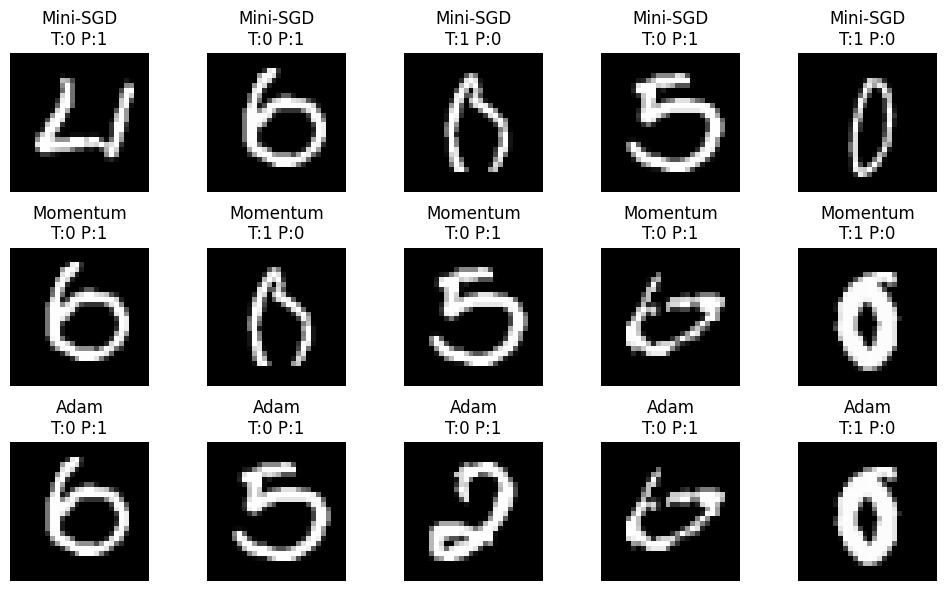


=== Training for digit 1 vs. not 1 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9896
SGD with Momentum    0.9929
   Adam Optimizer    0.9940


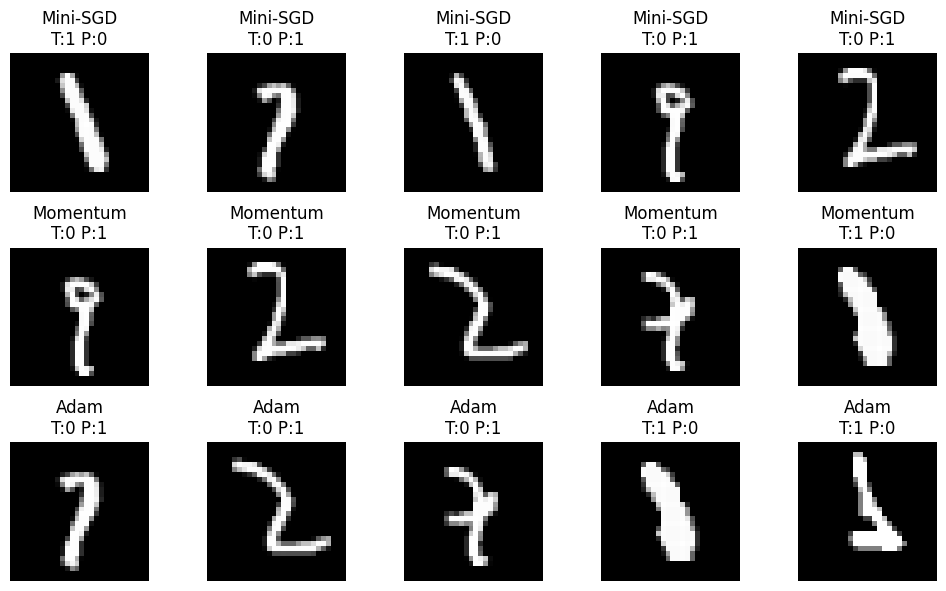


=== Training for digit 2 vs. not 2 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9740
SGD with Momentum    0.9810
   Adam Optimizer    0.9814


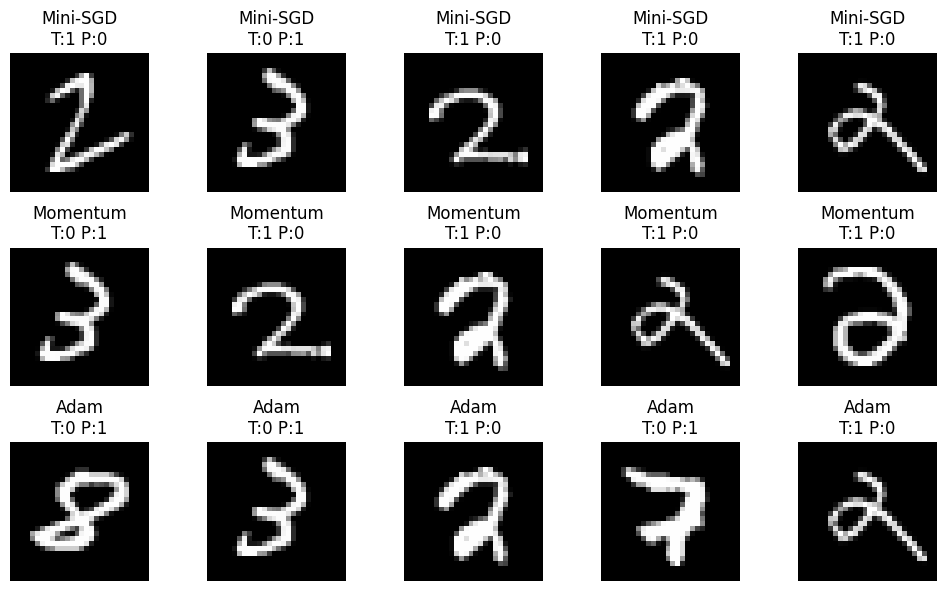


=== Training for digit 3 vs. not 3 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9686
SGD with Momentum    0.9772
   Adam Optimizer    0.9771


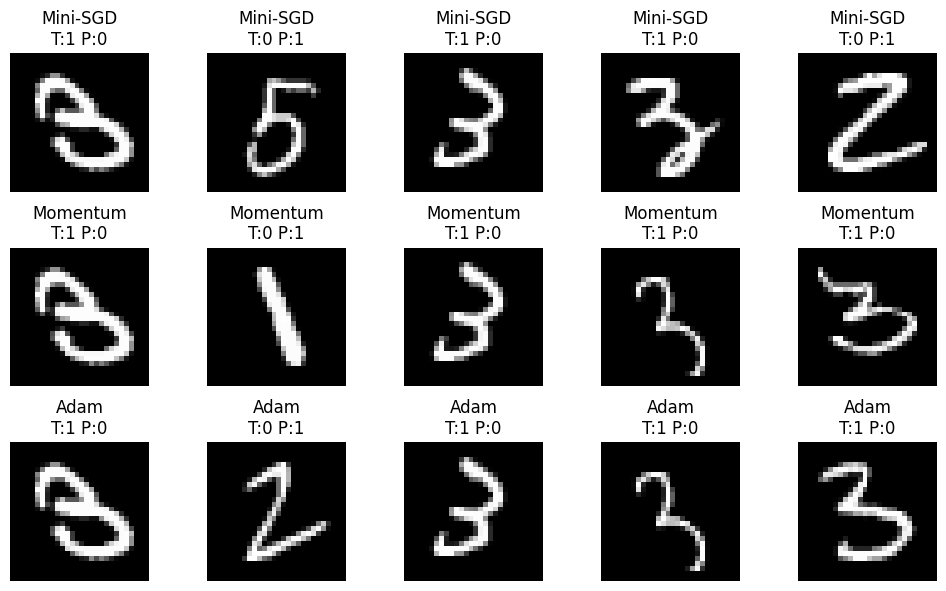


=== Training for digit 4 vs. not 4 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9749
SGD with Momentum    0.9806
   Adam Optimizer    0.9828


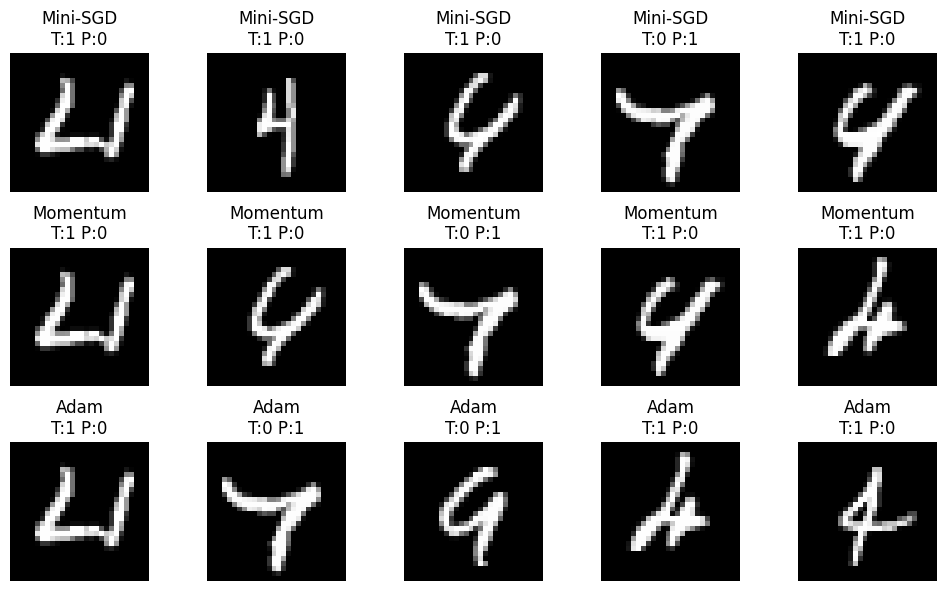


=== Training for digit 5 vs. not 5 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9617
SGD with Momentum    0.9737
   Adam Optimizer    0.9751


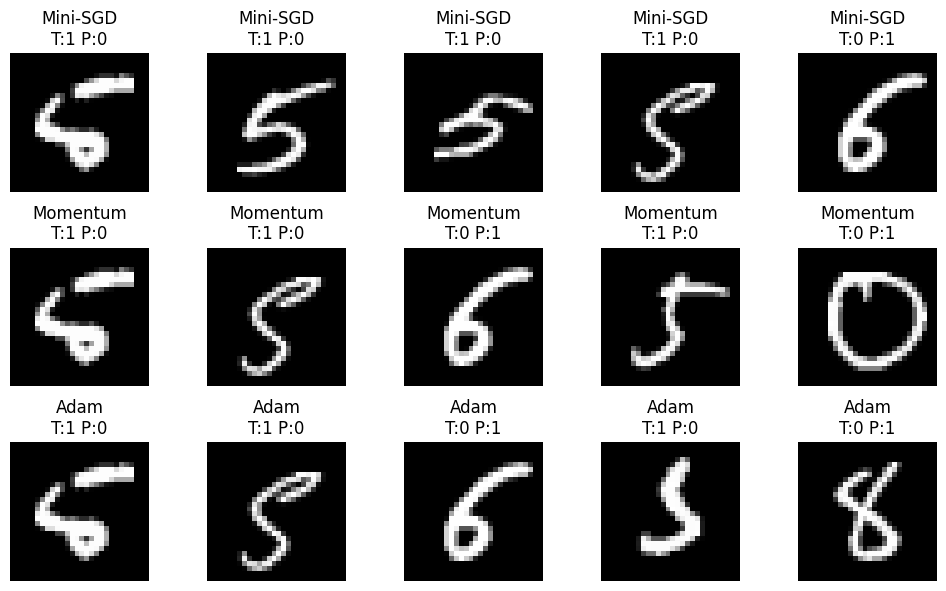


=== Training for digit 6 vs. not 6 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9811
SGD with Momentum    0.9860
   Adam Optimizer    0.9861


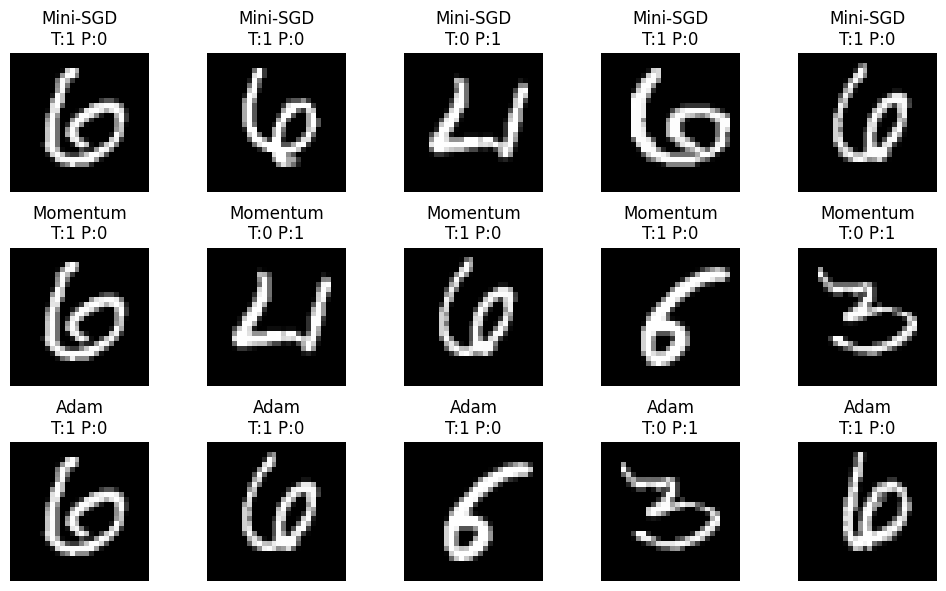


=== Training for digit 7 vs. not 7 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9806
SGD with Momentum    0.9847
   Adam Optimizer    0.9848


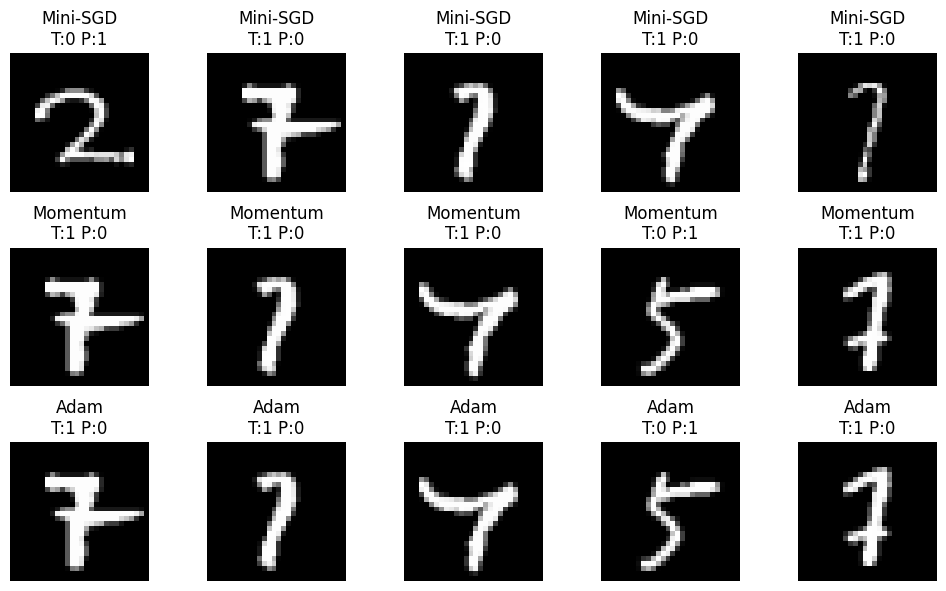


=== Training for digit 8 vs. not 8 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9451
SGD with Momentum    0.9600
   Adam Optimizer    0.9541


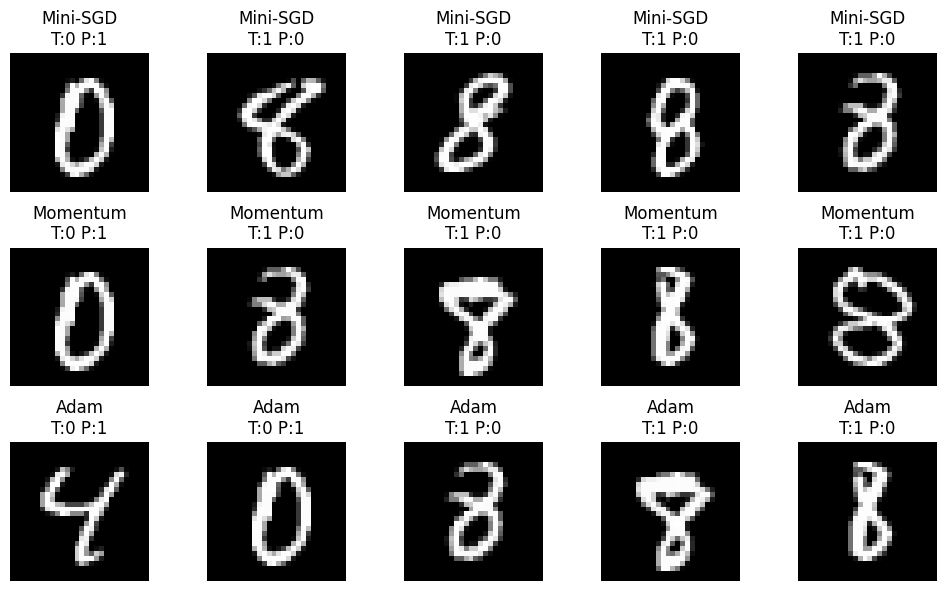


=== Training for digit 9 vs. not 9 ===

=== Performance Comparison ===
        Algorithm  Accuracy
   Mini-batch SGD    0.9568
SGD with Momentum    0.9640
   Adam Optimizer    0.9629


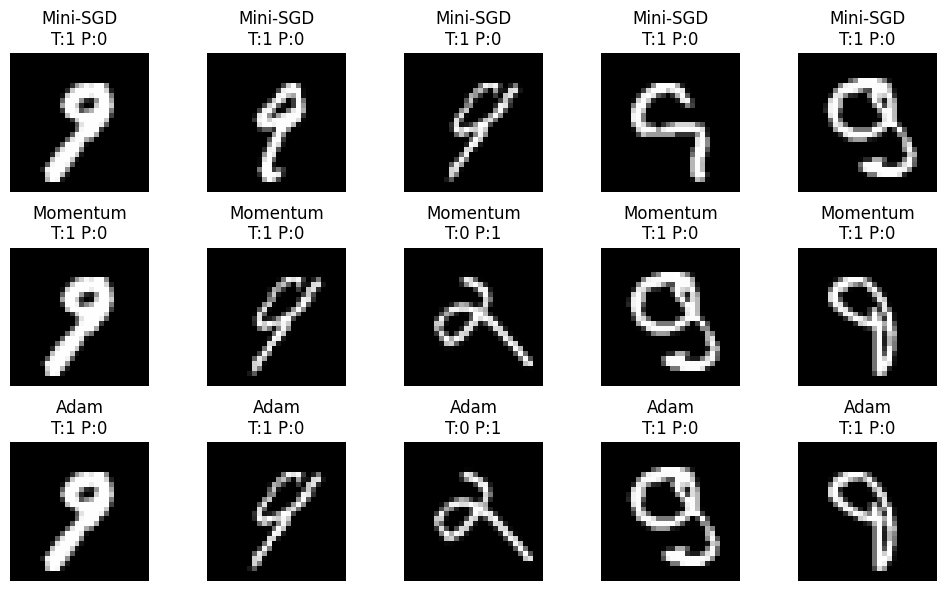

In [5]:
# ========== 3. Main ==========
if __name__ == "__main__":
    # === Load Data ===
    X_train_raw = load_images("train-images.idx3-ubyte__")
    y_train_raw = load_labels("train-labels.idx1-ubyte__")
    X_test_raw = load_images("t10k-images.idx3-ubyte__")
    y_test_raw = load_labels("t10k-labels.idx1-ubyte__")

    
    # === Add bias term ===
    X_train = np.hstack([np.ones((X_train_raw.shape[0], 1)), X_train_raw])
    X_test = np.hstack([np.ones((X_test_raw.shape[0], 1)), X_test_raw])

    # === Set parameters ===
    max_iters = 5000
    batch_size = 64
    learning_rate = 0.001  # Adjust depending on the optimizer


    all_results = []

    for digit in range(10):
        # === Choose binary classification target digit ===
        TARGET_DIGIT = digit   # TODO: Fill in (0 to 9)
        print(f"\n=== Training for digit {TARGET_DIGIT} vs. not {TARGET_DIGIT} ===")
        y_train_bin = np.where(y_train_raw == TARGET_DIGIT, 1, 0)
        y_test_bin = np.where(y_test_raw == TARGET_DIGIT, 1, 0)

        # === Train ===
        w_final_mini = sgd_minibatch(X_train, y_train_bin, eta=0.01, max_iters=max_iters, batch_size=batch_size)
        w_final_momentum = sgd_minibatch_momentum(X_train, y_train_bin, eta=0.01, max_iters=max_iters, batch_size=batch_size, momentum=0.9)
        w_final_Adam = sgd_Adam(X_train, y_train_bin, eta=learning_rate, max_iters=max_iters, batch_size=batch_size)

        # === Predict & Evaluate ===
        acc_mini, pred_mini = evaluate_optimizer("Mini-batch", w_final_mini, X_test, y_test_bin)
        acc_mom, pred_mom = evaluate_optimizer("Momentum", w_final_momentum, X_test, y_test_bin)
        acc_adam, pred_adam = evaluate_optimizer("Adam", w_final_Adam, X_test, y_test_bin)

        results = pd.DataFrame({
            "Algorithm": ["Mini-batch SGD", "SGD with Momentum", "Adam Optimizer"],
            "Accuracy": [acc_mini, acc_mom, acc_adam]
        })
        print("\n=== Performance Comparison ===")
        print(results.to_string(index=False))

        show_misclassified_comparison(X_test, y_test_bin, [pred_mini, pred_mom, pred_adam], 
                                 ["Mini-SGD", "Momentum", "Adam"])

## Learning Rate, Batch Size, Momentum Optimizer Experiments
Choose **Target Digit: 0** as experiment subject

### Learning Rate
LR: 0.1, 0.01, 0.001, 0.0001

In [6]:
# ==========================================
# Experiment 1: Learning Rate
# ==========================================
print("=== Experiment 1: Effect of Learning Rate ===")
TARGET_DIGIT = 0
y_train_bin = np.where(y_train_raw == TARGET_DIGIT, 1, 0)
y_test_bin = np.where(y_test_raw == TARGET_DIGIT, 1, 0)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
fixed_batch_size = 64
fixed_max_iters = 5000

results_lr = []

for lr in learning_rates:
    print(f"Testing Learning Rate: {lr}")
    
    w_mini = sgd_minibatch(X_train, y_train_bin, eta=lr, max_iters=fixed_max_iters, batch_size=fixed_batch_size)
    w_mom = sgd_minibatch_momentum(X_train, y_train_bin, eta=lr, max_iters=fixed_max_iters, batch_size=fixed_batch_size, momentum=0.9)
    w_adam = sgd_Adam(X_train, y_train_bin, eta=lr, max_iters=fixed_max_iters, batch_size=fixed_batch_size)

    acc_mini, _ = evaluate_optimizer("Mini-batch", w_mini, X_test, y_test_bin)
    acc_mom, _ = evaluate_optimizer("Momentum", w_mom, X_test, y_test_bin)
    acc_adam, _ = evaluate_optimizer("Adam", w_adam, X_test, y_test_bin)

    results_lr.append({
        "Learning Rate (eta)": lr,
        "Mini-batch SGD": acc_mini,
        "Momentum (0.9)": acc_mom,
        "Adam": acc_adam
    })

df_lr = pd.DataFrame(results_lr)
print("\n--- Learning Rate Experiment Results ---")
print(df_lr.to_string(index=False))

=== Experiment 1: Effect of Learning Rate ===
Testing Learning Rate: 0.1
Testing Learning Rate: 0.01
Testing Learning Rate: 0.001
Testing Learning Rate: 0.0001

--- Learning Rate Experiment Results ---
 Learning Rate (eta)  Mini-batch SGD  Momentum (0.9)   Adam
              0.1000          0.9918          0.9900 0.9903
              0.0100          0.9897          0.9920 0.9915
              0.0010          0.9766          0.9898 0.9927
              0.0001          0.9020          0.9765 0.9870


### Batch Size
Batch Size: 16, 64, 256, 1024

In [7]:
# ==========================================
# Experiment 2: Batch Size
# ==========================================
print("=== Experiment 2: Effect of Batch Size ===")
TARGET_DIGIT = 0
y_train_bin = np.where(y_train_raw == TARGET_DIGIT, 1, 0)
y_test_bin = np.where(y_test_raw == TARGET_DIGIT, 1, 0)

batch_sizes = [16, 64, 256, 1024]
fixed_max_iters = 5000

results_bs = []

for bs in batch_sizes:
    print(f"Testing Batch Size: {bs}")
    
    # Set learning rates for each optimizer
    w_mini = sgd_minibatch(X_train, y_train_bin, eta=0.01, max_iters=fixed_max_iters, batch_size=bs)
    w_mom = sgd_minibatch_momentum(X_train, y_train_bin, eta=0.01, max_iters=fixed_max_iters, batch_size=bs, momentum=0.9)
    w_adam = sgd_Adam(X_train, y_train_bin, eta=0.001, max_iters=fixed_max_iters, batch_size=bs)

    acc_mini, _ = evaluate_optimizer("Mini-batch", w_mini, X_test, y_test_bin)
    acc_mom, _ = evaluate_optimizer("Momentum", w_mom, X_test, y_test_bin)
    acc_adam, _ = evaluate_optimizer("Adam", w_adam, X_test, y_test_bin)

    results_bs.append({
        "Batch Size": bs,
        "Mini-batch SGD": acc_mini,
        "Momentum (0.9)": acc_mom,
        "Adam": acc_adam
    })

df_bs = pd.DataFrame(results_bs)
print("\n--- Batch Size Experiment Results ---")
print(df_bs.to_string(index=False))

=== Experiment 2: Effect of Batch Size ===
Testing Batch Size: 16
Testing Batch Size: 64
Testing Batch Size: 256
Testing Batch Size: 1024

--- Batch Size Experiment Results ---
 Batch Size  Mini-batch SGD  Momentum (0.9)   Adam
         16          0.9896          0.9923 0.9929
         64          0.9897          0.9913 0.9927
        256          0.9896          0.9920 0.9927
       1024          0.9898          0.9918 0.9927


### Momentum Optimizer
Only for SGD with momentum
Momentum: 0.0, 0.5, 0.9, 0.99

In [8]:
# ==========================================
# Experiment 3: Momentum
# ==========================================
print("=== Experiment 3: Effect of Momentum Coefficient ===")
TARGET_DIGIT = 0
y_train_bin = np.where(y_train_raw == TARGET_DIGIT, 1, 0)
y_test_bin = np.where(y_test_raw == TARGET_DIGIT, 1, 0)

momentums = [0.0, 0.5, 0.9, 0.99]
fixed_lr = 0.01
fixed_bs = 64
fixed_max_iters = 5000

results_mom = []

for mom in momentums:
    print(f"Testing Momentum Coefficient: {mom}")
    
    # SGD with Momentum
    w_mom = sgd_minibatch_momentum(
        X_train, y_train_bin, 
        eta=fixed_lr, 
        max_iters=fixed_max_iters, 
        batch_size=fixed_bs, 
        momentum=mom
    )

    acc_mom, _ = evaluate_optimizer("Momentum", w_mom, X_test, y_test_bin)

    results_mom.append({
        "Momentum Config": mom,
        "Accuracy (eta=0.01, bs=64)": acc_mom
    })

df_mom = pd.DataFrame(results_mom)
print("\n--- Momentum Experiment Results ---")
print(df_mom.to_string(index=False))

=== Experiment 3: Effect of Momentum Coefficient ===
Testing Momentum Coefficient: 0.0
Testing Momentum Coefficient: 0.5
Testing Momentum Coefficient: 0.9
Testing Momentum Coefficient: 0.99

--- Momentum Experiment Results ---
 Momentum Config  Accuracy (eta=0.01, bs=64)
            0.00                      0.9898
            0.50                      0.9914
            0.90                      0.9923
            0.99                      0.9919


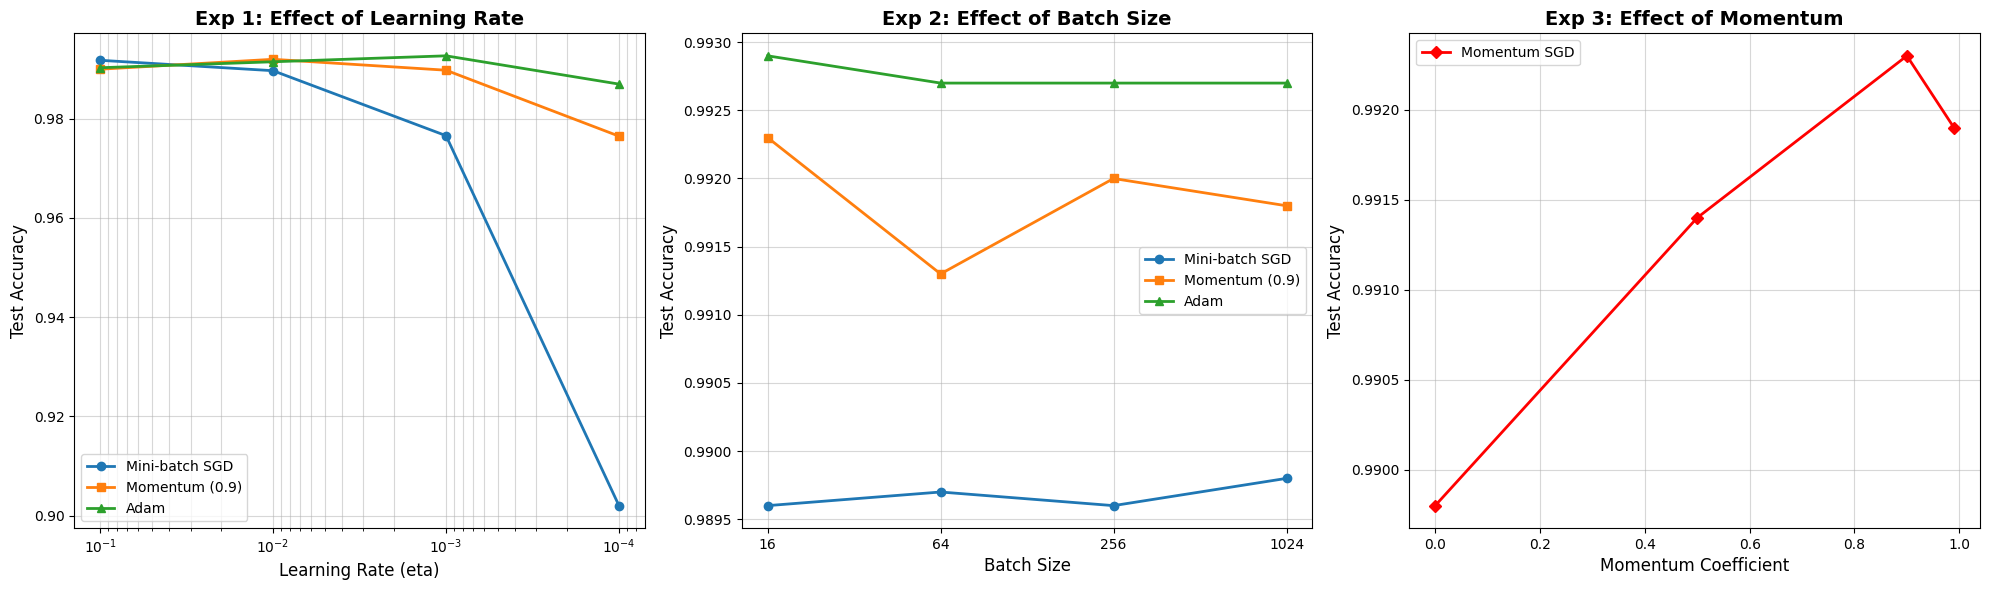

In [10]:
# 設定畫布大小 (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 圖 1: Learning Rate 實驗 ---
axes[0].plot(df_lr["Learning Rate (eta)"], df_lr["Mini-batch SGD"], marker='o', label='Mini-batch SGD', linewidth=2)
axes[0].plot(df_lr["Learning Rate (eta)"], df_lr["Momentum (0.9)"], marker='s', label='Momentum (0.9)', linewidth=2)
axes[0].plot(df_lr["Learning Rate (eta)"], df_lr["Adam"], marker='^', label='Adam', linewidth=2)
axes[0].set_xscale('log')  # 學習率通常使用對數座標
axes[0].invert_xaxis()
axes[0].set_xlabel('Learning Rate (eta)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Exp 1: Effect of Learning Rate', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, which="both", ls="-", alpha=0.5)

# --- 圖 2: Batch Size 實驗 ---
axes[1].plot(df_bs["Batch Size"], df_bs["Mini-batch SGD"], marker='o', label='Mini-batch SGD', linewidth=2)
axes[1].plot(df_bs["Batch Size"], df_bs["Momentum (0.9)"], marker='s', label='Momentum (0.9)', linewidth=2)
axes[1].plot(df_bs["Batch Size"], df_bs["Adam"], marker='^', label='Adam', linewidth=2)
axes[1].set_xscale('log', base=2)  # Batch size 常用 2 的次方，使用 log2 座標
axes[1].set_xticks(batch_sizes)
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter()) # 讓座標顯示數字而非科學記號
axes[1].set_xlabel('Batch Size', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Exp 2: Effect of Batch Size', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, which="both", ls="-", alpha=0.5)

# --- 圖 3: Momentum 係數實驗 ---
axes[2].plot(df_mom["Momentum Config"], df_mom["Accuracy (eta=0.01, bs=64)"], marker='D', color='red', linewidth=2, label='Momentum SGD')
axes[2].set_xlabel('Momentum Coefficient', fontsize=12)
axes[2].set_ylabel('Test Accuracy', fontsize=12)
axes[2].set_title('Exp 3: Effect of Momentum', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, ls="-", alpha=0.5)

# 優化間距並顯示
plt.tight_layout()
plt.show()